## Backends


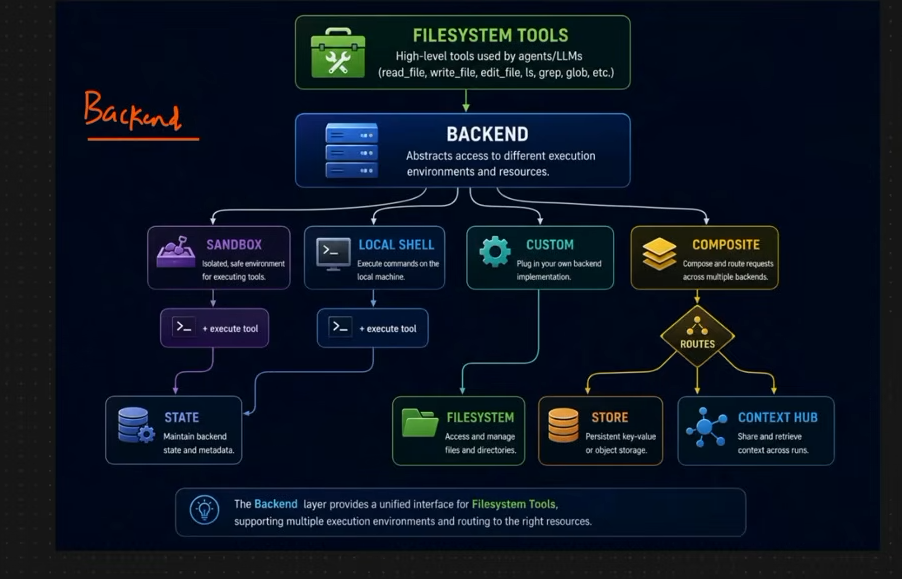

### Understanding Backends in Deep Agents

**The big idea:** A deep agent needs to read and write files (like a person needs a notebook to write things down). But *where* does that notebook actually live? On your laptop? In the cloud? In a safe sandbox? The agent shouldn't have to care — that's the whole point of the **Backend**.

Think of it like a **universal remote control**.

- **Filesystem Tools (top, green):** These are the *buttons* the agent presses — `read_file`, `write_file`, `edit_file`, `ls`, `glob`, etc. The agent always presses the same buttons no matter what.
- **Backend (blue, middle):** This is the *remote control's brain*. It takes the button press ("write this file") and figures out where to actually send that command. The agent never has to know the details — it just presses buttons and trusts the backend to route them correctly.

### The four "TVs" the remote can control

These are the four different places the files could actually live:

1. **Sandbox (purple):** A locked, safe playroom. The agent can make a mess here — create, delete, run things — and it can't break anything in the real world. Great for letting an AI "execute" risky stuff safely.
2. **Local Shell (blue):** The real computer sitting on your desk. Files actually get written to your real hard drive.
3. **Custom (teal):** A "build your own" slot. If you have some special place you want files stored (your own database, your own server), you plug it in here.
4. **Composite (gold):** This is the clever one — it's not one place, it's a *router*. It looks at the request and decides "this goes here, that goes there," splitting traffic between:
   - **Filesystem (green):** actual files/folders
   - **Store (orange):** a persistent key-value storage box, like a locker that remembers things between sessions
   - **Context Hub (cyan):** a shared place multiple agent runs can pull from and drop info into, like a group chat everyone can read

> **TL;DR:** The Backend gives the agent one simple, unified way to use file tools — no matter which "world" (sandbox, local machine, custom system, or a mix of several) it's actually plugged into underneath.

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

### StateBackend

In [4]:
import os
from deepagents import create_deep_agent
from deepagents.backends import StateBackend

In [5]:
# Create the agent 
agent = create_deep_agent(model = "groq:qwen/qwen3.6-27b")

# under the hood this is what 'agent' is doing - explicit StateBackend 
agent2 = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b", 
    backend=StateBackend()
)

In [6]:
# Invoke the agent and ask it to WRITE a file 
# (StateBackend keeps that file inside the LangGraph state)

result = agent2.invoke({
    "messages": [{
        "role": "user", 
        "content": (
            "Create a file at /notes/todo.txt with exactly this content:\n"
            "1. Record vidoe\n2. Edit video\n3. Upload video\n"
            "Then tell me you've done it"
        )
    }]
})

# The agent's final natural-language reply
print("\n--- Agent reply -------------------------------------------------")
print(result["messages"][-1].content)


--- Agent reply -------------------------------------------------
Done! I've created `/notes/todo.txt` with your list.


In [7]:
result

{'messages': [HumanMessage(content="Create a file at /notes/todo.txt with exactly this content:\n1. Record vidoe\n2. Edit video\n3. Upload video\nThen tell me you've done it", additional_kwargs={}, response_metadata={}, id='199d8bbd-87ff-4437-b282-72251a0ba822'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants me to create a file at /notes/todo.txt with specific content. Then I need to confirm that I've done it.\nLet me create the file with the exact content requested.\n", 'tool_calls': [{'id': '0y2ffat3t', 'function': {'arguments': '{"content":"1. Record vidoe\\n2. Edit video\\n3. Upload video","file_path":"/notes/todo.txt"}', 'name': 'write_file'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 2763, 'total_tokens': 2862, 'completion_time': 0.244475398, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.235778425, 'prompt_tokens_details': None, 'queue_time': 0.074181242, 'total_t

In [8]:
# CHECK the backend is working
# With StateBackend, written files appear under result["files"]
print("\n--- Backend check -----------------------------------------------")
files = result.get("files", {})

if files:
    print(f"✅ StateBackend is working — {len(files)} file(s) in state:")
    for path, content in files.items():
        print(f"\n📄 {path}\n{'-' * 40}\n{content}")
else:
    print("⚠️  No files found in state. Either the agent didn't write a file, "
          "or the backend isn't wired up correctly.")




--- Backend check -----------------------------------------------
✅ StateBackend is working — 1 file(s) in state:

📄 /notes/todo.txt
----------------------------------------
{'content': '1. Record vidoe\n2. Edit video\n3. Upload video', 'encoding': 'utf-8', 'created_at': '2026-08-23T16:38:45.158667+00:00', 'modified_at': '2026-08-23T16:38:45.158667+00:00'}


In [9]:
# Prove persistence WITHIN the same thread:
# feed the returned state back in and ask it to READ the file

followup = agent2.invoke({
    # carry forward prior messages + the files state
    "messages": result["messages"] + [{
        "role": "user",
        "content": "Read /notes/todo.txt back to me ."
    }],
    "files": result.get("files", {}),   # <-- pass the virtual filesystem along
})

print("\n--- Read-back (same thread) -------------------------------------")
print(followup["messages"][-1].content)




--- Read-back (same thread) -------------------------------------
Here is the content of `/notes/todo.txt`:

1. Record vidoe
2. Edit video
3. Upload video


### File System Backend (local disk)

In [10]:
# Create the agent with a real-disk backend 
# root dir = "." -> files land relative to your current working directory 
# virtual_mode = True -> agent uses virutal paths like /notes/todo.txt, mapped onto root_dir 

from deepagents.backends import FilesystemBackend
ROOT = "."

agent = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b", 
    backend = FilesystemBackend(root_dir=ROOT, virtual_mode=True)
)

print(f"✅ Agent created with FilesystemBackend(root_dir={ROOT!r}).")
print("   Files written by the agent will appear on your ACTUAL disk.")

✅ Agent created with FilesystemBackend(root_dir='.').
   Files written by the agent will appear on your ACTUAL disk.


In [11]:
# invoke the agent and ask it to WRITE a file 

result = agent.invoke({
    "messages": [{
        "role": "user", 
        "content": (
            "Create a file at /notes/todo.txt with exactly this content:\n"
            "1. Record video\n2. Edit video\n3. Upload video\n"
            "Then tell me you've done it"
        )
    }]
})

print("\n--- Agent reply --------------------------------------------------")
print(result["messages"][-1].content)


--- Agent reply --------------------------------------------------
Done! I've created `/notes/todo.txt` with your three to-do items.


In [12]:
# check the backend is working - Look on the REAL disk 
# With virutal_mode = True, /notes/todo.txt maps to ./notes/todo.txt 

from pathlib import Path 
print("\n--- Backend check (real filesystem) ----------------------")
disk_path = Path(ROOT) / "notes" /"todo.txt"

if disk_path.exists():
    print(f"✅ FilesystemBackend is working — file exists on disk:")
    print(f"📄 {disk_path.resolve()}\n{'-' * 40}")
    print(disk_path.read_text())
else:
    print(f"⚠️  Expected file not found at {disk_path.resolve()}")
    print("    The agent may not have called the write tool, or the path "
          "mapping differs.")


--- Backend check (real filesystem) ----------------------
✅ FilesystemBackend is working — file exists on disk:
📄 C:\Users\manas\Documents\development\langgraph-learning\src\deepagents\notes\todo.txt
----------------------------------------
1. Record video
2. Edit video
3. Upload video


In [12]:
# Prove persistence ACROSS sessions 
# Unlike StateBackend, this file survives even after Python exists. 
# A brand new agent (fresh state) can read it back from disk 

fresh_agent = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b", 
    backend= FilesystemBackend(root_dir=ROOT, virtual_mode=True)
)

followup = fresh_agent.invoke({
    "messages": [{
        "role": "user", 
        "content": "Read /notes/todo.txt back to me verbatim"
    }]
    # NOTE: no 'files' state passed in - the file is read straight from disk 
})

print("\n--- Read-back with a FRESH agent (proves disk persistence) ------")
print(followup["messages"][-1].content)


--- Read-back with a FRESH agent (proves disk persistence) ------
1. Record video
2. Edit video
3. Upload video


### StoreBackend Verification 

Creates a deep agent backed by a LangGraph store, invokes it to write a file on one thread, then proves the backend works by reading that file back on a DIFFERENT thread - something StateBackend cannot do """

### Understanding `StoreBackend` and Namespaces

**What it is:** `StoreBackend` stores files inside a **LangGraph store** — not in RAM tied to one thread (`StateBackend`), and not on your real disk (`FilesystemBackend`). It's a third place entirely: a persistent, key-based storage layer.

**How a file is actually addressed:**
A file in `StoreBackend` isn't identified by its path alone (`/notes.txt`). It's identified by **`namespace + path` together**. The same path in two different namespaces = two completely separate, unrelated files.

```python
backend=StoreBackend(
    namespace=lambda rt: (rt.context.user_id,),   # decides WHICH bucket a file goes into
)
```

- `namespace` is a **function you write**, run fresh on every call.
- It can be **static** (`lambda rt: ("demo-user",)`) — everyone shares one bucket. Good for quick local testing only.
- It can be **dynamic** (`lambda rt: (rt.context.user_id,)`) — each real user gets their own private bucket, automatically.
- Namespaces can be stacked for finer grouping: `(user_id, project_id)`, `("team", team_id)`, role-based, time-based, etc.

**Key behavior — cross-thread persistence:**
Unlike `StateBackend` (tied to one thread's memory), `StoreBackend` doesn't care about `thread_id` at all. Write a file on Thread A, read it back on a completely unrelated Thread B — as long as both resolve to the **same namespace**, they see the same files.

**Important — it's not "one big shared file, filtered by user":**
Each namespace is fully separate storage. There's no single giant `/notes.txt` that gets filtered per user at read-time. Alice's `/notes.txt` and Bob's `/notes.txt` are two independent files in two independent buckets that just happen to share a name.

---

### 🔑 Analogy: A Gym With Named Lockers

- **The gym** → the `store`
- **A locker** → a `namespace` (e.g. `"alice"`, `"bob"`, `"team-marketing"`)
- **Shelf labels inside a locker** (e.g. "Notes," "Todo") → file paths (`/notes.txt`, `/todo.txt`)
- **Showing your gym ID at the door** → the namespace function deciding which locker is "yours" (dynamically, based on `rt.context`)
- **Visiting the gym multiple times (different threads/conversations)** → doesn't matter how many separate visits — same ID always opens **the same locker**, with everything still there from last time
- **Someone else's locker** → totally inaccessible, even if their shelf has the *exact same label* as yours — same label, different locker, zero leakage



In [13]:
from langgraph.store.memory import InMemoryStore
from deepagents.backends import StoreBackend
store = InMemoryStore()


agent = create_deep_agent(
    model="groq:qwen/qwen3.6-27b", 
    backend=StoreBackend(
        # Local dev: static namespace. No deployment runtime needed.
        # In a LangSmith Deployment you'd use the user-identity version.
        namespace=lambda rt: ("demo-user",),
    ),
    store=store,
)

print("✅ Agent created with StoreBackend + static namespace.")

✅ Agent created with StoreBackend + static namespace.


In [14]:
import os
import uuid

# THREAD 1 — write a file
thread_1 = {"configurable": {"thread_id": str(uuid.uuid4())}}

result = agent.invoke(
    {
        "messages": [{
            "role": "user",
            "content": (
                "Create a file at /notes/todo.txt with exactly this content:\n"
                "1. Record video\n2. Edit video\n3. Upload video\n"
                "Then tell me you've done it."
            )
        }]
    },
    config=thread_1,
)

print("\n--- Agent reply (thread 1) --------------------------------------")
print(result["messages"][-1].content)


--- Agent reply (thread 1) --------------------------------------
Done! I've created the file at `/notes/todo.txt` with the three todo items.


In [16]:
# Thread 2: read back on a different thread 

thread_2 = {'configurable': {'thread_id': str(uuid.uuid4())}}
followup = agent.invoke({
    "messages": [{
        "role": "user", 
        "content": "Read /notes/todo.txt back to me verbatim"
    }]
}, 
config = thread_2, 
)

print("\n--- Read-back on a different thread ---")
print(followup["messages"][-1].content)


--- Read-back on a different thread ---
1. Record video
2. Edit video
3. Upload video


# Deep Agent Backends — Where Your Files Actually Live

Every Deep Agent works with a **virtual filesystem**: its tools read and write
files using paths like `/notes/todo.txt`. But those paths are an abstraction.
The **backend** decides where that data physically lives — and that single
choice changes everything about persistence, sharing, and durability.

The agent code stays identical across all three. Only the backend changes.

---

## 1. StateBackend (default)

Files live **in the agent's LangGraph state** — i.e. in RAM, tied to a single
thread. They're available during the run via `result["files"]`, and you must
manually carry that state forward to keep using them.

- **Where:** in-memory dict, inside one thread's state
- **Survives:** within a single conversation/thread only
- **Gone when:** the thread ends or the process exits
- **Use it for:** ephemeral scratch space, temporary working files

## 2. FilesystemBackend

Files are written to your **real disk**, under `root_dir`. With
`virtual_mode=True`, a virtual path like `/notes/todo.txt` maps to
`root_dir/notes/todo.txt`. These are genuine files you can open in an editor
or `cat` from a terminal.

- **Where:** your actual filesystem, relative to `root_dir`
- **Survives:** across process restarts — it's a real file
- **Use it for:** when the agent should edit real project files
- **⚠️ Caution:** grants the agent real read/write disk access — point it at a scratch directory, not anything important

## 3. StoreBackend

Files live in a **LangGraph store**, scoped by a `namespace`. This is the only
backend whose files persist **across threads/conversations** — write on one
thread, read back on another. With `InMemoryStore` this works within a single
process; swap in a persistent store (e.g. Postgres-backed) for true
cross-restart durability.

- **Where:** inside the store object, under a namespace key
- **Survives:** across threads sharing the same store
- **Gone when:** the process exits (if using `InMemoryStore`) — use a persistent store to outlive restarts
- **Use it for:** long-term memory, per-user file spaces

---

## Quick comparison

| Backend | Lives in | Cross-thread? | Survives restart? | Real file on disk? |
|---|---|---:|---:|---:|
| `StateBackend` | LangGraph state | ❌ | ❌ | ❌ |
| `FilesystemBackend` | Your disk | ✅ | ✅ | ✅ |
| `StoreBackend` | A LangGraph store | ✅ | Only with persistent store | ❌ |




> **Mental model:** the agent never knows the difference. Its tools always
> speak in file paths — the backend quietly translates every read/write into
> the right operation underneath. That's what lets you swap backends without
> touching a line of agent logic.